# Lecture 17: Boosting

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(406)

## Generate Data

We'll generate data from a piecewise linear function with some noise.

In [2]:
# Generate data from a piecewise linear function
n = 100
x_train = np.sort(np.random.uniform(0, 10, n))

# Piecewise linear function: y = 0.5*x for x < 5, y = -0.5*x + 5 for x >= 5
def true_function(x):
    return np.where(x < 5, 0.5 * x, -0.5 * x + 5)

y_train = true_function(x_train) + np.random.normal(0, 0.1, n)

# Dense grid for smooth plotting
x_grid = np.linspace(0, 10, 500)
y_true = true_function(x_grid)

print(f"Generated {n} training points")

Generated 100 training points


## Define Step Function Weak Learner

The weak learner is a simple step function with a single parameter $t$ (the step location):

$$
\hat h(x) = \begin{cases}
0 & x < t \\
c & x \geq t
\end{cases}
$$

In [3]:
def fit_step_function(x, y):
    """
    Fit a step function to data by finding optimal step location and height.

    Returns:
        dict with 't' (step location) and 'c' (step height)
    """
    best_mse = np.inf
    best_t = None
    best_c = None

    # Try each unique x value as a potential step location
    for t in np.unique(x):
        # Fit constant on left and right of step
        left_idx = x < t
        right_idx = x >= t

        if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
            continue

        # Left side predicts 0, right side predicts mean
        c_right = np.mean(y[right_idx])
        predictions = np.where(x < t, 0, c_right)
        mse = np.mean((y - predictions)**2)

        if mse < best_mse:
            best_mse = mse
            best_t = t
            best_c = c_right

    return {'t': best_t, 'c': best_c}

def predict_step(x_new, t, c):
    """Predict using step function."""
    return np.where(x_new < t, 0, c)

In [4]:
# Number of boosting iterations to run
max_iterations = 25

# Initialize
f_current = np.zeros(len(x_train))  # Current ensemble prediction on training data
f_grid = np.zeros(len(x_grid))       # Current ensemble prediction on grid
residuals = y_train.copy()           # Initial residuals

# Store results for each iteration
results = []

for iter in range(1, max_iterations + 1):
    # Fit weak learner to current residuals
    weak_learner = fit_step_function(x_train, residuals)

    # Make predictions
    h_train = predict_step(x_train, weak_learner['t'], weak_learner['c'])
    h_grid = predict_step(x_grid, weak_learner['t'], weak_learner['c'])

    # Use a learning rate (shrinkage) for stability
    alpha = 0.3

    # Update ensemble
    f_current = f_current + alpha * h_train
    f_grid = f_grid + alpha * h_grid

    # Update residuals
    residuals = y_train - f_current

    # Store results
    results.append({
        'iter': iter,
        't': weak_learner['t'],
        'c': weak_learner['c'],
        'alpha': alpha,
        'f_grid': f_grid.copy(),
        'f_train': f_current.copy(),
        'h_grid': alpha * h_grid,
        'residuals': residuals.copy()
    })

print(f"Completed {max_iterations} boosting iterations")

Completed 25 boosting iterations


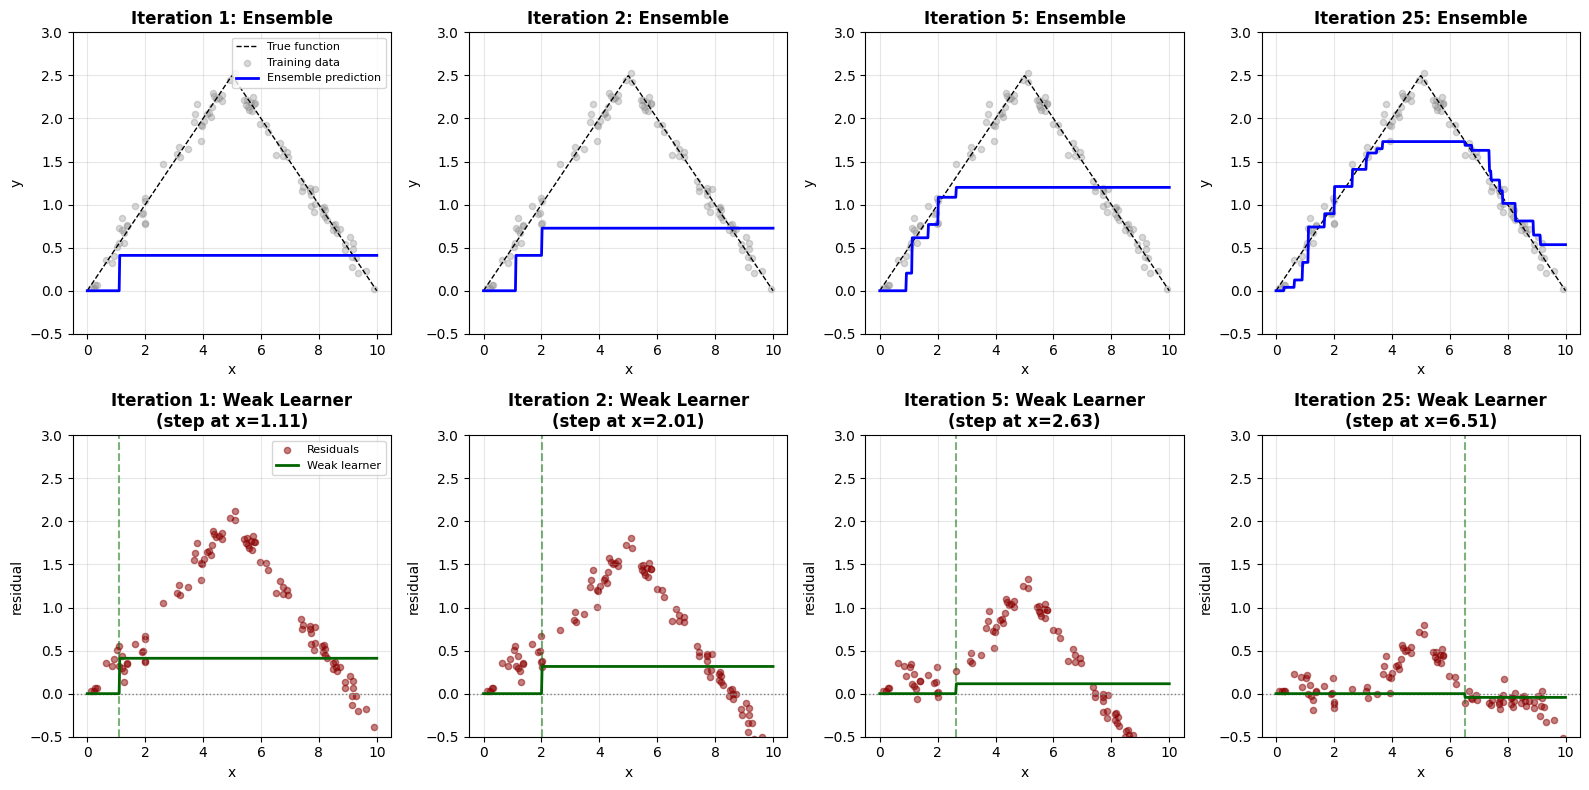

In [5]:
# Select specific iterations to display
iterations_to_show = [1, 2, 5, 25]

# Create plots: 2 rows x len(iterations_to_show) columns
fig, axes = plt.subplots(2, len(iterations_to_show), figsize=(4 * len(iterations_to_show), 8))

for col_idx, iter_num in enumerate(iterations_to_show):
    res = results[iter_num - 1]  # 0-indexed

    # Top row: Ensemble prediction vs true function
    ax_ensemble = axes[0, col_idx]
    ax_ensemble.plot(x_grid, y_true, 'k--', linewidth=1, label='True function')
    ax_ensemble.scatter(x_train, y_train, alpha=0.3, s=20, color='gray', label='Training data')
    ax_ensemble.plot(x_grid, res['f_grid'], color='blue', linewidth=2, label='Ensemble prediction')
    ax_ensemble.set_ylim(-0.5, 3)
    ax_ensemble.set_xlabel('x')
    ax_ensemble.set_ylabel('y')
    ax_ensemble.set_title(f"Iteration {res['iter']}: Ensemble", fontweight='bold')
    if col_idx == 0:
        ax_ensemble.legend(loc='upper right', fontsize=8)
    ax_ensemble.grid(True, alpha=0.3)

    # Bottom row: Weak learner fit on residuals
    ax_residual = axes[1, col_idx]
    ax_residual.axhline(y=0, color='gray', linestyle=':', linewidth=1)
    ax_residual.scatter(x_train, res['residuals'], alpha=0.5, s=20, color='darkred', label='Residuals')
    ax_residual.plot(x_grid, res['h_grid'], color='darkgreen', linewidth=2, label='Weak learner')
    ax_residual.axvline(x=res['t'], color='darkgreen', linestyle='--', alpha=0.5)
    ax_residual.set_ylim(-0.5, 3)
    ax_residual.set_xlabel('x')
    ax_residual.set_ylabel('residual')
    ax_residual.set_title(f"Iteration {res['iter']}: Weak Learner\n(step at x={res['t']:.2f})", fontweight='bold')
    if col_idx == 0:
        ax_residual.legend(loc='upper right', fontsize=8)
    ax_residual.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/boosting_demo.svg')
plt.show()